In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import healpy as hp
import astropy
import skyproj
import healsparse

In [2]:
NSIDE = 32
RING = True
NEST = not RING
LONLAT = True

NPIX = hp.nside2npix(NSIDE)

In [3]:
mosaics = [0, 1, 2, 3]

In [4]:
imcom_dtheta = 1.3616557734204793e-05
imcom_lonpole = 180.0
imcom_Nside = 2040
imcom_nblock = 40

In [5]:
mosaic_crval = {
    0: (9.55, -42.98888889),
    1: (9.55, -44.1),
    2: (11.05, -42.98888889),
    3: (11.05, -44.1),
}

In [6]:
mosaic_wcs = {}
mosaic_footprints = {}
for mosaic in mosaics:
    _mosaic_nside = imcom_Nside * imcom_nblock
    _mosaic_wcs = astropy.wcs.WCS(header={"NAXIS1": _mosaic_nside, "NAXIS2": _mosaic_nside}, naxis=2)
    _mosaic_wcs.wcs.crpix = [
        (_mosaic_nside + 1) / 2.0,
        (_mosaic_nside + 1) / 2.0,
    ]
    _mosaic_wcs.wcs.cdelt = [-imcom_dtheta, imcom_dtheta]
    _mosaic_wcs.wcs.ctype = ["RA---STG", "DEC--STG"]
    _mosaic_wcs.wcs.crval = mosaic_crval[mosaic]
    _mosaic_wcs.wcs.lonpole = imcom_lonpole

    mosaic_wcs[mosaic] = _mosaic_wcs
    
    mosaic_wcs_footprint = _mosaic_wcs.calc_footprint()
    
    mosaic_footprints[mosaic] = mosaic_wcs_footprint

In [7]:
survey_center = np.mean(
    [
        mosaic_footprints[0][0],
        mosaic_footprints[1][1],
        mosaic_footprints[2][3],
        mosaic_footprints[3][2],
    ],
    axis=0,
)

In [8]:
mosaic_healpixels = {}
for mosaic in mosaics:
    mosaic_wcs_footprint = mosaic_footprints[mosaic]
    covering_healpixels = hp.query_polygon(
        NSIDE,
        hp.ang2vec(mosaic_wcs_footprint[:, 0], mosaic_wcs_footprint[:, 1], lonlat=LONLAT),
        inclusive=True,
        nest=NEST,
        fact=max(4, 4096 // NSIDE),
    )
    covering_healpixels = np.unique(covering_healpixels)
    mosaic_healpixels[mosaic] = covering_healpixels
    print(f"{mosaic} HEALPix: {covering_healpixels}")

0 HEALPix: [10179 10307 10430]
1 HEALPix: [10307 10430 10431]
2 HEALPix: [10179 10180 10307 10308 10431]
3 HEALPix: [10307 10308 10431]


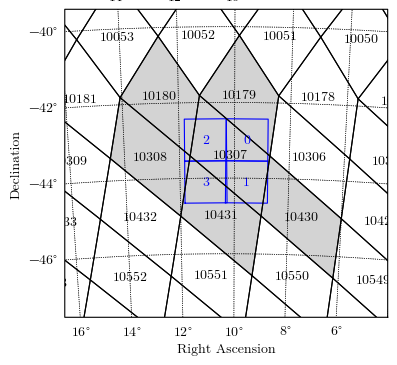

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

dt=4
sp = skyproj.GnomonicSkyproj(
    ax=ax,
    lon_0=survey_center[0],
    lat_0=survey_center[1],
    extent=[
        survey_center[0] - dt / np.cos(np.radians(survey_center[1])),
        survey_center[0] + dt / np.cos(np.radians(survey_center[1])),
        survey_center[1] - dt,
        survey_center[1] + dt,
    ],
)

for mosaic in mosaics:
    sp.draw_polygon(
        mosaic_footprints[mosaic][:, 0],
        mosaic_footprints[mosaic][:, 1],
        edgecolor="b",
        # lw=plt.rcParams['axes.linewidth'] * 2,
        label=f"Mosaic {mosaic}",
    )
    _mosaic_wcs = mosaic_wcs[mosaic]
    _ra, _dec = _mosaic_wcs.wcs.crval
    sp.ax.text(_ra, _dec, mosaic, c="b", lonlat=LONLAT, ha='center', va='center')

indices = np.unique(np.concatenate(list(mosaic_healpixels.values())))
neighbors = np.unique(np.concatenate([
    hp.get_all_neighbours(NSIDE, *hp.pix2ang(NSIDE, i, lonlat=LONLAT), nest=NEST, lonlat=LONLAT)
    for i in indices
]))
neighbors = np.unique(np.concatenate([
    hp.get_all_neighbours(NSIDE, *hp.pix2ang(NSIDE, i, lonlat=LONLAT), nest=NEST, lonlat=LONLAT)
    for i in neighbors
]))
neighbors = np.unique(np.concatenate([
    hp.get_all_neighbours(NSIDE, *hp.pix2ang(NSIDE, i, lonlat=LONLAT), nest=NEST, lonlat=LONLAT)
    for i in neighbors
]))
for i in np.setdiff1d(neighbors, indices):
    _boundary = hp.boundaries(NSIDE, i, step=1, nest=NEST).T
    _boundary_ra, _boundary_dec = hp.vec2ang(_boundary, lonlat=LONLAT)
    sp.draw_polygon(_boundary_ra, _boundary_dec, edgecolor='k')

    ra, dec = hp.pix2ang(NSIDE, i, nest=NEST, lonlat=LONLAT)
    sp.ax.text(ra, dec, i, lonlat=LONLAT, ha='center', va='center', clip_on=True)

for i in indices:
    _boundary = hp.boundaries(NSIDE, i, step=1, nest=NEST).T
    _boundary_ra, _boundary_dec = hp.vec2ang(_boundary, lonlat=LONLAT)
    sp.draw_polygon(_boundary_ra, _boundary_dec, edgecolor='k', facecolor='lightgray')

    ra, dec = hp.pix2ang(NSIDE, i, nest=NEST, lonlat=LONLAT)
    sp.ax.text(ra, dec, i, lonlat=LONLAT, ha='center', va='center', clip_on=True)

sp.ax.tick_params(axis="x", labelsize=plt.rcParams["xtick.labelsize"])
sp.ax.tick_params(axis="y", labelsize=plt.rcParams["ytick.labelsize"])
sp.ax.set_xlabel("Right Ascension", fontsize=plt.rcParams["xtick.labelsize"])                                         
sp.ax.set_ylabel("Declination", fontsize=plt.rcParams["ytick.labelsize"])

plt.show()